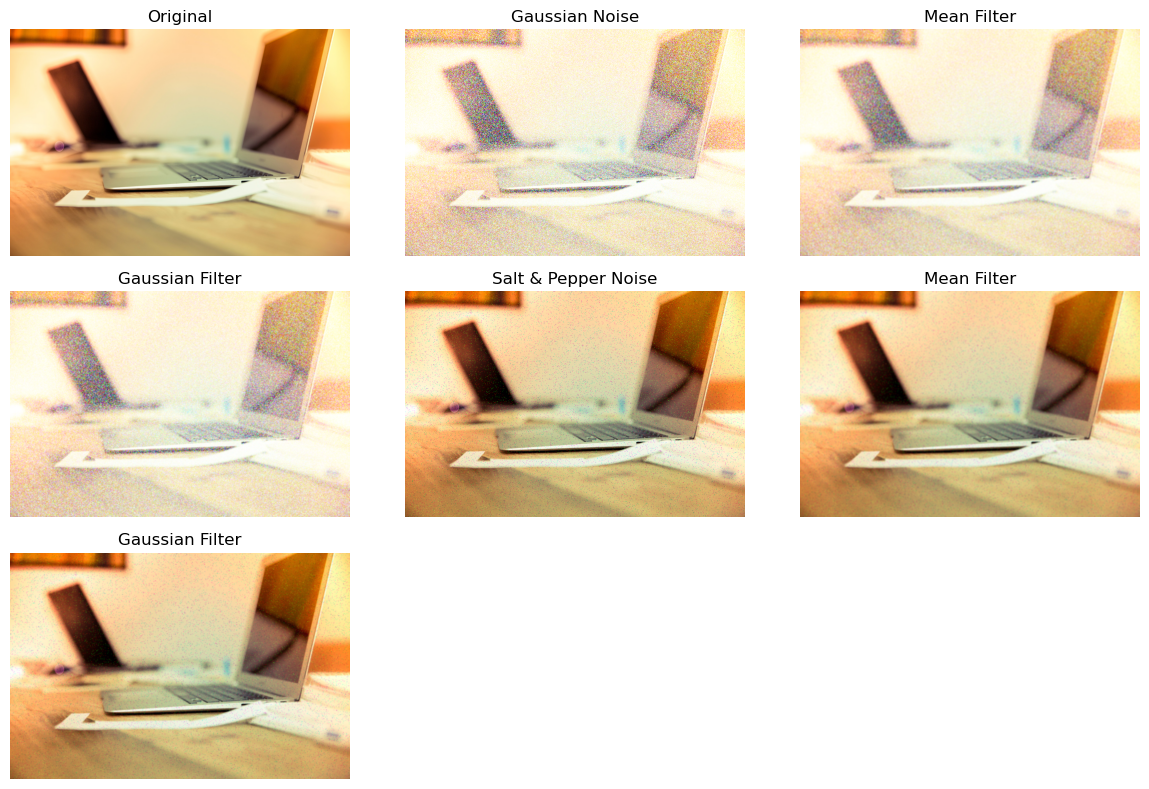

In [ ]:
#lab-01
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('sample_image.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Function to add Gaussian noise
def add_gaussian_noise(image):
    mean = 0
    sigma = 25
    gaussian = np.random.normal(mean, sigma, image.shape).astype('uint8')
    noisy = cv2.add(image, gaussian)
    return noisy

# Function to add Salt & Pepper noise
def add_salt_pepper_noise(image):
    noisy = np.copy(image)
    prob = 0.02

    # Salt
    num_salt = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255

    # Pepper
    num_pepper = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0

    return noisy

# Add noise
gaussian_noisy = add_gaussian_noise(img)
sp_noisy = add_salt_pepper_noise(img)

# Apply filters
mean_gaussian = cv2.blur(gaussian_noisy, (5,5))
mean_sp = cv2.blur(sp_noisy, (5,5))

gauss_gaussian = cv2.GaussianBlur(gaussian_noisy, (5,5), 0)
gauss_sp = cv2.GaussianBlur(sp_noisy, (5,5), 0)

# Show results
titles = ['Original', 'Gaussian Noise', 'Mean Filter', 'Gaussian Filter',
          'Salt & Pepper Noise', 'Mean Filter', 'Gaussian Filter']

images = [img, gaussian_noisy, mean_gaussian, gauss_gaussian,
          sp_noisy, mean_sp, gauss_sp]

plt.figure(figsize=(12,8))
for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

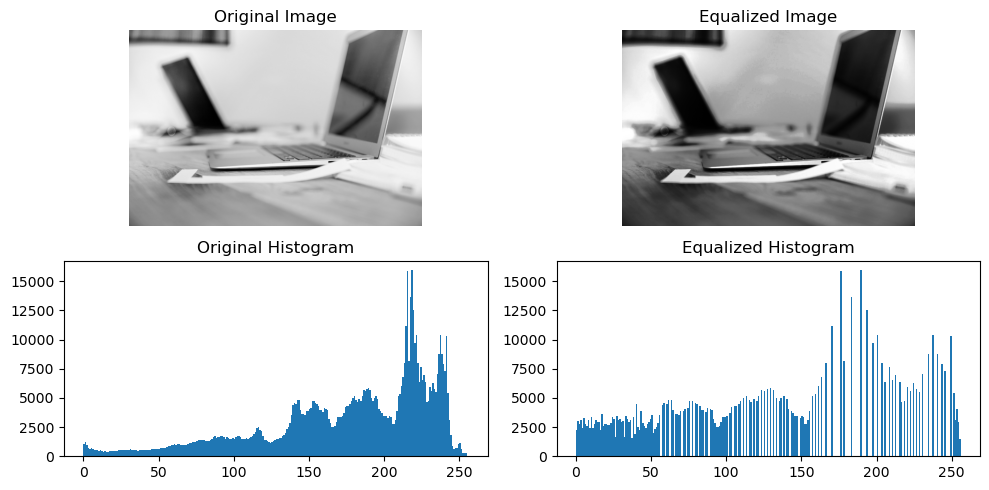

In [3]:
#lab-02
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread('sample_image.jpg', 0)

# Apply histogram equalization
equalized = cv2.equalizeHist(img)

# Plot images
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(equalized, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

# Plot histograms
plt.subplot(2,2,3)
plt.hist(img.ravel(), bins=256, range=[0,256])
plt.title('Original Histogram')

plt.subplot(2,2,4)
plt.hist(equalized.ravel(), bins=256, range=[0,256])
plt.title('Equalized Histogram')

plt.tight_layout()
plt.show()

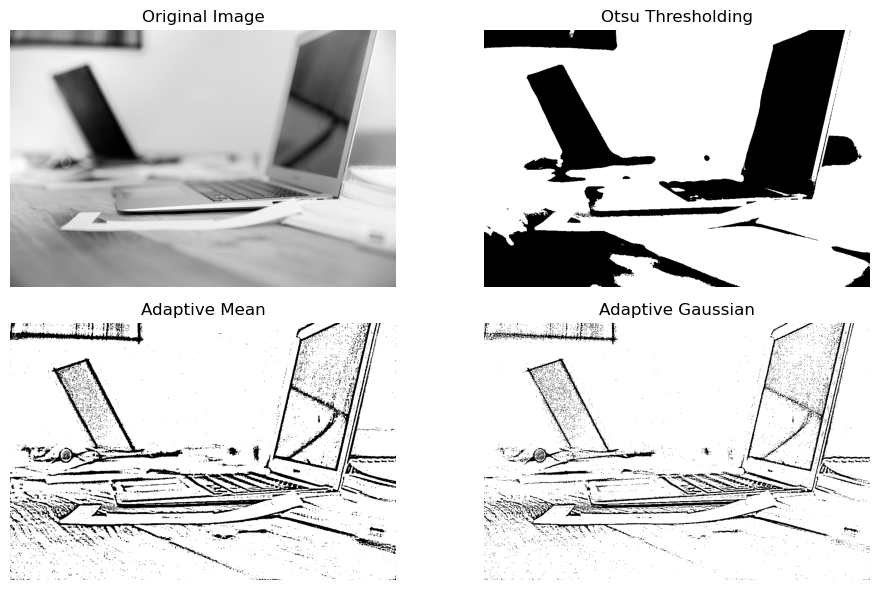

In [4]:
#lab-03
import cv2
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread('sample_image.jpg', 0)

# 1. Global Thresholding (Otsu)
_, otsu_thresh = cv2.threshold(img, 0, 255, 
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Adaptive Thresholding (Mean)
adaptive_mean = cv2.adaptiveThreshold(img, 255,
                                      cv2.ADAPTIVE_THRESH_MEAN_C,
                                      cv2.THRESH_BINARY,
                                      11, 2)

# 3. Adaptive Thresholding (Gaussian)
adaptive_gaussian = cv2.adaptiveThreshold(img, 255,
                                          cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY,
                                          11, 2)

# Plot results
titles = ['Original Image', 'Otsu Thresholding',
          'Adaptive Mean', 'Adaptive Gaussian']

images = [img, otsu_thresh, adaptive_mean, adaptive_gaussian]

plt.figure(figsize=(10,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

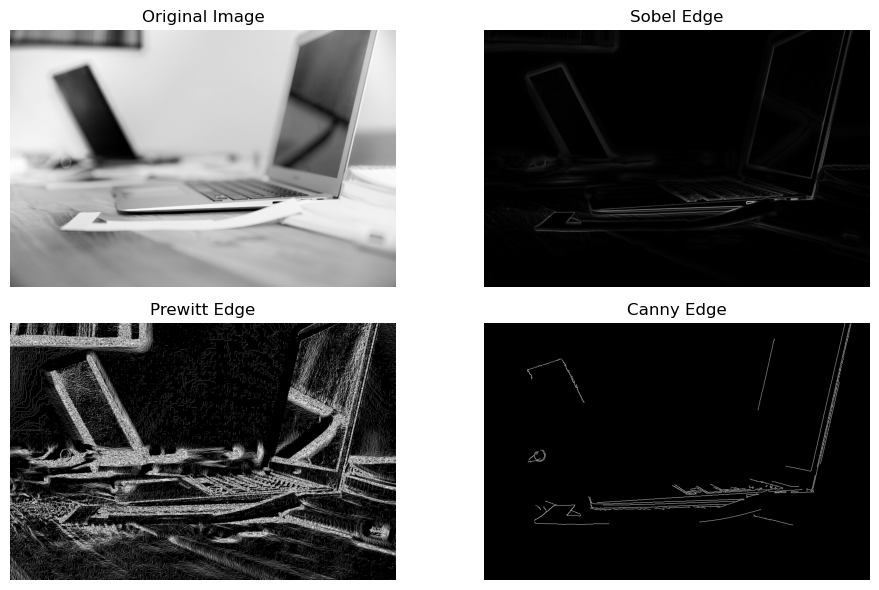

In [ ]:
#lab-4
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread('sample_image.jpg', 0)

# Sobel Edge Detection
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

# Prewitt Edge Detection (manual kernels)
kernelx = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
kernely = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])

prewittx = cv2.filter2D(img, -1, kernelx)
prewitty = cv2.filter2D(img, -1, kernely)
prewitt = np.sqrt(prewittx**2 + prewitty**2)

# Canny Edge Detection
canny = cv2.Canny(img, 100, 200)

# Plot results
titles = ['Original Image', 'Sobel Edge', 'Prewitt Edge', 'Canny Edge']
images = [img, sobel, prewitt, canny]

plt.figure(figsize=(10,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#lab-5
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('sample_image.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply thresholding
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

# Noise removal (optional)
kernel = np.ones((3,3), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours left to right
contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

# Draw bounding boxes and extract characters
char_images = []
output = img.copy()

for i, cnt in enumerate(contours):
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Filter small noise
    if w > 10 and h > 10:
        char = thresh[y:y+h, x:x+w]
        char_images.append(char)
        
        # Draw rectangle
        cv2.rectangle(output, (x,y), (x+w, y+h), (0,255,0), 2)

# Show results
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Characters")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(thresh, cmap='gray')
plt.title("Binary Image")
plt.axis('off')

plt.show()

# Show segmented characters
for i, char in enumerate(char_images):
    plt.imshow(char, cmap='gray')
    plt.title(f'Character {i+1}')
    plt.axis('off')
    plt.show()

Total number of rice grains: 7
Rice 1: Area=12574.0, Perimeter=1212.34, Major Axis Length=326.93
Rice 2: Area=8869.0, Perimeter=1137.61, Major Axis Length=178.76
Rice 3: Area=17.0, Perimeter=15.66, Major Axis Length=6.72
Rice 4: Area=2565.0, Perimeter=302.21, Major Axis Length=105.45
Rice 5: Area=18.0, Perimeter=12.83, Major Axis Length=5.33
Rice 6: Area=9.0, Perimeter=8.00, Major Axis Length=3.27
Rice 7: Area=6644.0, Perimeter=1104.70, Major Axis Length=169.44

Rice grains within area range: 0


C:\Users\HP\AppData\Local\Temp\ipykernel_18120\4086658473.py:39: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  major_axes.append(prop.major_axis_length)
C:\Users\HP\AppData\Local\Temp\ipykernel_18120\4086658473.py:45: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  f"Major Axis Length={prop.major_axis_length:.2f}")


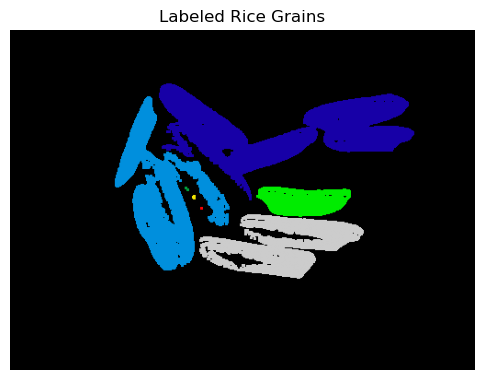

In [9]:
# lab-6
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

# Load image
img = cv2.imread('12.jpg', 0)

# Apply thresholding (Otsu)
_, thresh = cv2.threshold(img, 0, 255, 
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert if necessary (rice should be white)
thresh = cv2.bitwise_not(thresh)

# Remove noise using morphological opening
kernel = np.ones((3,3), np.uint8)
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Label connected components
labels = measure.label(clean, connectivity=2)

# Get properties
properties = measure.regionprops(labels)

# Count rice grains
rice_count = len(properties)
print("Total number of rice grains:", rice_count)

# Lists to store features
areas = []
perimeters = []
major_axes = []

for prop in properties:
    areas.append(prop.area)
    perimeters.append(prop.perimeter)
    major_axes.append(prop.major_axis_length)

# Display properties
for i, prop in enumerate(properties):
    print(f"Rice {i+1}: Area={prop.area}, "
          f"Perimeter={prop.perimeter:.2f}, "
          f"Major Axis Length={prop.major_axis_length:.2f}")

# Filter by specific area range
min_area = 100
max_area = 1000

filtered = [prop for prop in properties if min_area <= prop.area <= max_area]
print("\nRice grains within area range:", len(filtered))

# Plot labeled image
plt.figure(figsize=(6,6))
plt.imshow(labels, cmap='nipy_spectral')
plt.title("Labeled Rice Grains")
plt.axis('off')
plt.show()

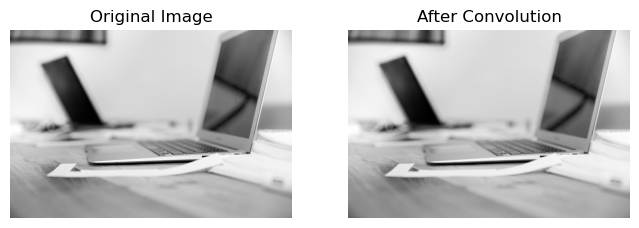

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('sample_image.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Define 3x3 kernel (choose one)
kernel = np.array([[1,1,1],
                   [1,1,1],
                   [1,1,1]]) / 9   # Mean filter

# Apply convolution
output = cv2.filter2D(img, -1, kernel)

# Show results
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output, cmap='gray')
plt.title('After Convolution')
plt.axis('off')

plt.show()

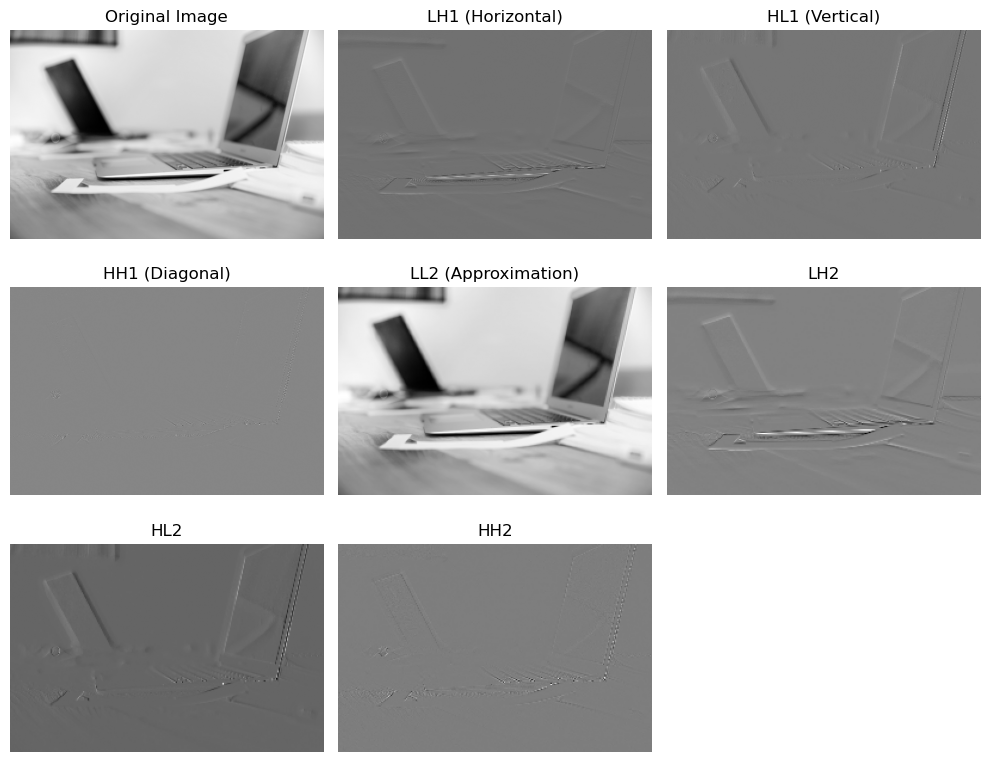

In [11]:
#lab-8
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread('sample_image.jpg', 0)

# Perform 2-level DWT
coeffs = pywt.wavedec2(img, 'haar', level=2)

# Extract coefficients
LL2, (LH2, HL2, HH2), (LH1, HL1, HH1) = coeffs

# Plot results
plt.figure(figsize=(10,8))

plt.subplot(3,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Level 1
plt.subplot(3,3,2)
plt.imshow(LH1, cmap='gray')
plt.title('LH1 (Horizontal)')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(HL1, cmap='gray')
plt.title('HL1 (Vertical)')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(HH1, cmap='gray')
plt.title('HH1 (Diagonal)')
plt.axis('off')

# Level 2
plt.subplot(3,3,5)
plt.imshow(LL2, cmap='gray')
plt.title('LL2 (Approximation)')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(LH2, cmap='gray')
plt.title('LH2')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(HL2, cmap='gray')
plt.title('HL2')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(HH2, cmap='gray')
plt.title('HH2')
plt.axis('off')

plt.tight_layout()
plt.show()